In [2]:
from USGSreportmaker import ReportMaker
from datetime import datetime, timedelta, UTC
from zoneinfo import ZoneInfo
import manage_reports
from embeds import make_mmi_embed
import discord
import numpy as np
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import cartopy.crs as ccrs
from shapely.geometry import Polygon, Point, shape, box
import textwrap
import geopandas as gpd
import requests
from pprint import pprint

from cartopy.mpl.geoaxes import GeoAxes

In [7]:
quake_id = "testid6"
quake_timestamp = "1689734792000"
update_timestamp = "1689934792000"


with open("data/notable_quakes.txt",'a') as f:
    f.write(f"{quake_id} {quake_timestamp} {update_timestamp}\n")

In [33]:
timestamp_now = int(datetime.now().timestamp() * 1000)
time_since_quake = timedelta(milliseconds=timestamp_now - int(quake_timestamp))
deadline = timedelta(days=5)
print(time_since_quake.days)
print(time_since_quake > deadline)

1111
True


In [8]:
# read in lines
with open("data/notable_quakes.txt","r") as f:
    lines = f.readlines()

id_to_delete = "testid2"

# only write lines that are not to be deleted
with open("data/notable_quakes.txt","w") as f:
    for line in lines:
        quake_id, quake_timestamp, update_timestamp = line.split()
        print(quake_id)
        print(quake_timestamp)
        print(update_timestamp)
        if id_to_delete not in line:
            f.write(line)

testid6
1689734792000
1689934792000
testid6
1689734792000
1689934792000


In [ ]:
def get_quakes_to_update():
    """ Updates list of notable quake reports to update.

    Assumes that data/notable_quakes.txt is written during check_quakes.

    - Fetches ID and earthquake timestamp
    - Checks time since earthquake
    - If less than 5 days since, query earthquake and update message
    - If more than 5 days since, remove from list and stop updating
    (Generally, most USGS DYFI responses are in by about 5 days for M>5.0 quakes)
    
    Returns:
    - quakes_to_update (list): list of quake IDs to update.
    """
    quakes_to_update = []
    # current time
    timestamp_now = int(datetime.now().timestamp() * 1000)
    deadline = timedelta(days=5)

    # read in lines
    with open("data/notable_quakes.txt","r") as f:
        lines = f.readlines()

    # only write lines that are not to be deleted
    with open("data/notable_quakes.txt","w") as f:
        for line in lines:
            quake_id, quake_timestamp = line.split()
            time_since_quake = timedelta(milliseconds=(timestamp_now-int(quake_timestamp)))
            if time_since_quake < deadline:
                # if timestamp is less than 5 days ago, write. Otherwise ignore and stop updating
                quakes_to_update.append(quake_id)
                f.write(line)

    return quakes_to_update

In [14]:
query = {
        "format": "geojson",
        "eventid": "nc216859"
    }

In [ ]:
rm = ReportMaker()
rm.load_ev_detail()

event  = rm.data['features'][0]
pprint(rm.ev_detail)
# origin = event['properties']['products']['origin'][0]['properties']

# pprint(origin['latitude'])
# pprint(event['properties']['products']['origin'][0]['properties'])

Fetched USGS data for query.
Loaded report:
M 3.3 - 17 km E of Desert Hot Springs, CA
Aug 01, 2026 09:51 AM
{'geometry': {'coordinates': [-116.320999145508,
                              33.9786682128906,
                              7.28999996185303],
              'type': 'Point'},
 'id': 'ci40664738',
 'properties': {'alert': None,
                'cdi': 2.7,
                'code': '40664738',
                'dmin': 0.0822,
                'felt': 43,
                'gap': 28,
                'ids': ',ci40664738,us6000thh8,',
                'mag': 3.32960193254778,
                'magType': 'ml',
                'mmi': None,
                'net': 'ci',
                'nst': 118,
                'place': '17 km E of Desert Hot Springs, CA',
                'products': {'dyfi': [{'code': 'ci40664738',
                                       'contents': {'cdi_geo.txt': {'contentType': 'text/plain',
                                                                    'lastModified

: 

In [20]:
rm.load_ev_detail()
rm.make_eew_map(show=True)

Loaded report:
M 6.9 - The 1989 Loma Prieta, California Earthquake
Oct 17, 1989 05:04 PM
Event has no ShakeAlert product.
No EEW was issued for this event.


No losspager. Using dyfi txt


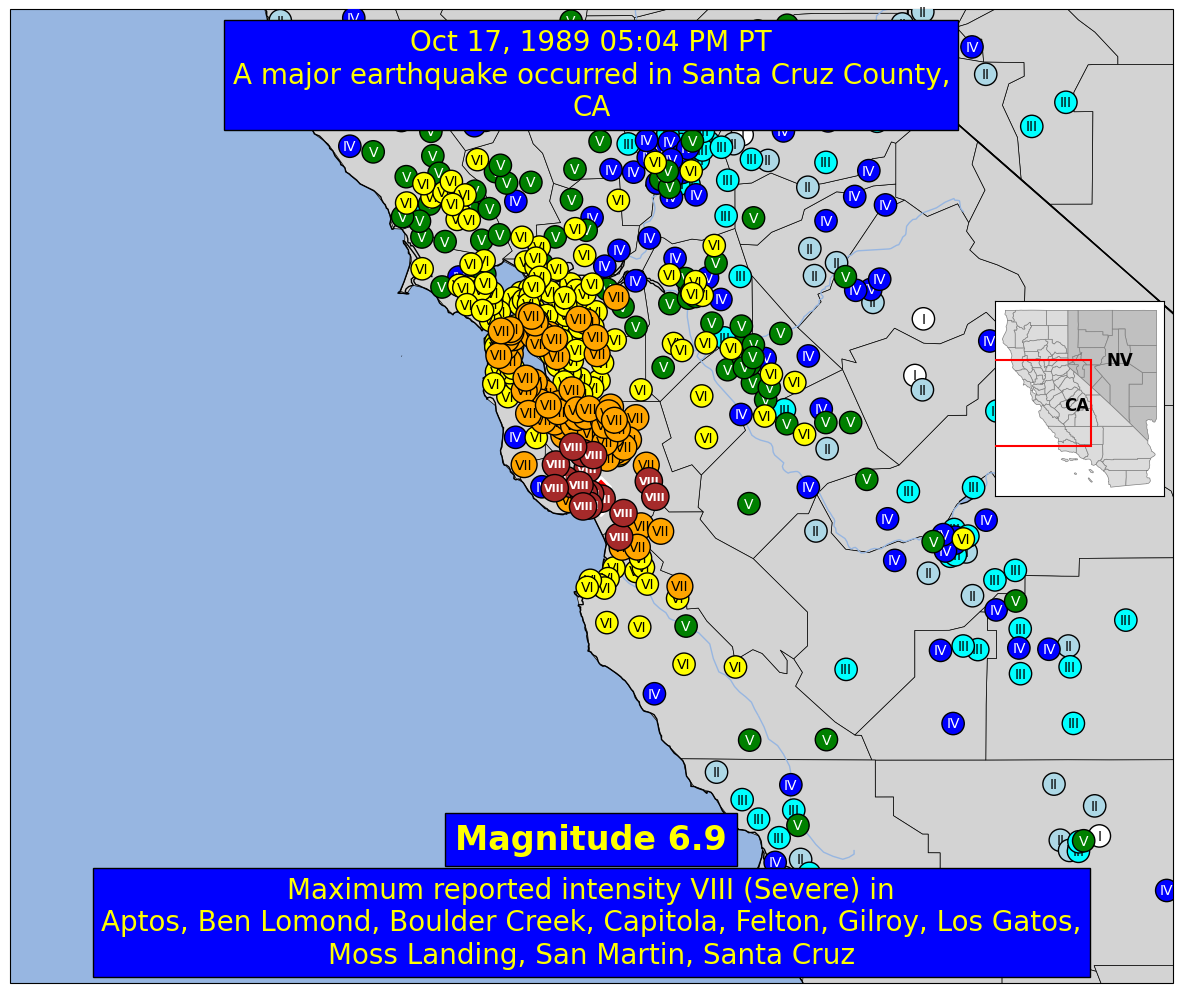

In [22]:
rm.make_mmi_map(show=True)


In [ ]:
rm.load_ev_detail(1426)
rm.get_eew_data()
ca_nv = rm.ca_nv
# order by distance to epicenter
ca_nv["epi_dist"] = ca_nv.geometry.distance(Point(rm.eew_epix,rm.eew_epiy))
ca_nv = ca_nv.sort_values(by="epi_dist")
ca_nv["intersect_area"] = ca_nv.geometry.intersection(rm.alert_poly).area
ca_nv["cover_ratio"] = ca_nv["intersect_area"] / ca_nv.geometry.area

ca_nv["warned"] = (ca_nv["cover_ratio"] > 0.05)
print(all(ca_nv['warned']) == False)
ca_nv.loc[ca_nv.index[0], 'warned'] = True
l = ca_nv[ca_nv['warned']==True]['NAME'].tolist()
l

KeyError: 'warned'

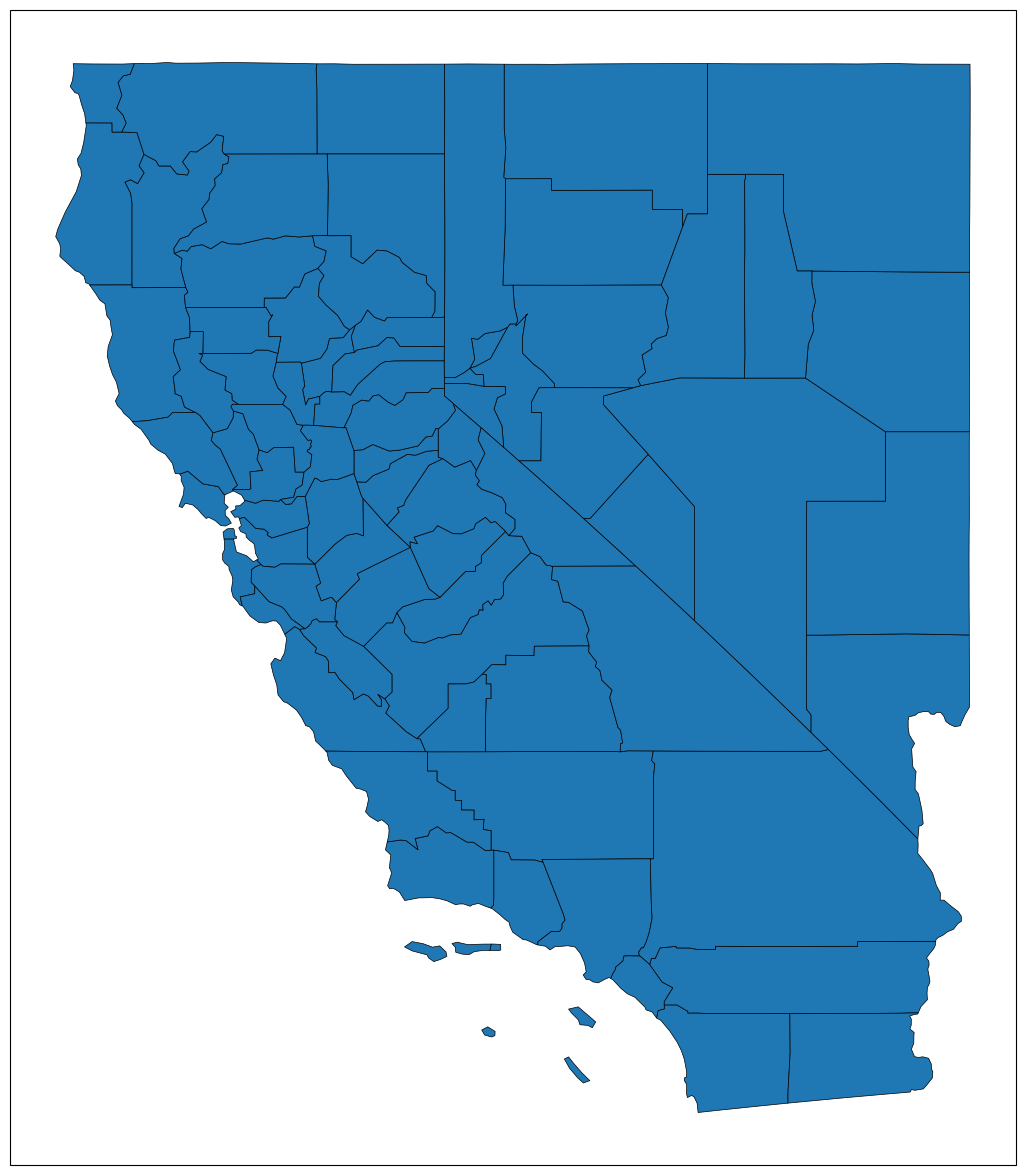

In [5]:
fig, axi = plt.subplots(1,1,figsize=(15,15), subplot_kw={'projection': ccrs.PlateCarree()})

rm.ca_nv.plot(ax=axi,color=rm.alert_colors,edgecolor='black',linewidth=0.5)

# poly_diameter = minimum_bounding_radius(alert_poly) * 2
# print(poly_diameter)
# poly_diameter = max(poly_diameter,1)
# map_lims = [epix - poly_diameter, epix + poly_diameter, epiy - poly_diameter/1.5, epiy + poly_diameter/1.5]
pad = 1.5
x1, y1, x2, y2 = rm.ca_nv[rm.ca_nv['warned']==True].total_bounds
map_lims = (x1 - pad, x2 + pad, y1 - pad/1.5, y2 + pad/1.5)
try:
    axi.set_extent(map_lims)
except:
    axi.set_extent(rm.lims)

# axi.add_feature(cfeature.COASTLINE)
# axi.add_feature(cfeature.BORDERS, linestyle=':')
axi.add_feature(cfeature.LAND, edgecolor='black')
axi.add_feature(cfeature.LAKES, edgecolor='black')
axi.add_feature(cfeature.RIVERS)
axi.add_feature(cfeature.STATES)
axi.add_feature(cfeature.OCEAN)

desc = rm.mag_style(rm.eew_mag)
epi_mask = rm.ca_nv.contains(Point(rm.eew_epix,rm.eew_epiy))
name_from_fp = lambda fp: "CA" if fp == '06' else "NV"
if epi_mask.any():
    # if epicenter is within a polygon
    epi_county = rm.ca_nv[epi_mask]['NAME'].to_list()[0]
    epi_statefp = rm.ca_nv[epi_mask]['STATEFP'].to_list()[0]
    print(epi_statefp)
    epi_state = name_from_fp(epi_statefp)
    rm.eew_caption = f'{desc} was detected in {epi_county} County, {epi_state}'
else:
    #if epicenter is off all polygons (assumes offshore)
    # better method needed for events onshore off region (e.g. in Oregon, Utah, Mexico, etc.)
    county_closest = rm.ca_nv.distance(Point(rm.eew_epix,rm.eew_epiy)).sort_values().index[0]
    epi_county = rm.ca_nv.loc[county_closest]["NAME"]
    epi_statefp = rm.ca_nv.loc[county_closest]['STATEFP']
    epi_state = name_from_fp(epi_statefp)
    rm.eew_caption = f'{desc} was detected off {epi_county} County, {epi_state}'

ew_style = dict(boxstyle='square', facecolor='red', edgecolor='black')
axi.text(0.5,0.98,'EARTHQUAKE WARNING',transform=axi.transAxes,fontsize=36,color='w',fontweight='bold',bbox=ew_style,va='top',ha='center')

psa_text = "Drop, cover, hold on.\nShaking expected in the following counties:"
if rm.regions_used: psa_text = "Drop, cover, hold on.\nShaking expected in the following regions/counties:"
psa_style = dict(boxstyle='square', facecolor='blue', edgecolor='black')
axi.text(0.5,0.91,psa_text,transform=axi.transAxes,fontsize=16,color='yellow',bbox=psa_style,va='top',ha='center')

warn_text = "\n".join(textwrap.wrap("        ".join(rm.formatted_warned_areas), width=60))
clist_style = dict(boxstyle='square', facecolor='blue', edgecolor='k', pad=0.6)
axi.text(0.5,0.05,warn_text,transform=axi.transAxes,fontsize=18,color='w',fontweight='bold',bbox=clist_style,va='bottom',ha='center')

axi.scatter(rm.eew_epix,rm.eew_epiy,marker='X',c='r',ec='white',linewidths=2,s=750)
# plot_polygon(alert_poly)

# axi.set_title(f"Example: {event['properties']['title']}, threshold {MMI}")

axins = axi.inset_axes([0.845,0.4,0.15,0.2])
# axins = axi.inset_axes([0.845,0.5,0.15,0.2])
# axins.set_xlim(rm.lims[0],rm.lims[1])
# axins.set_ylim(rm.lims[2],rm.lims[3])
axins.text(0.66,0.67,"NV",transform=axins.transAxes,fontsize=12,fontweight='bold',color='black')
axins.text(0.41,0.44,"CA",transform=axins.transAxes,fontsize=12,fontweight='bold',color='black')
# state_colors = rm.ca_nv['STATEFP'].map({'06': 'gold', '32': 'royalblue'})
state_colors = rm.ca_nv['STATEFP'].map({'06': 'gainsboro', '32': 'silver'})
rm.ca_nv.plot(ax=axins,color=state_colors,edgecolor='gray',linewidth=0.5)
axins.set_xticks([])
axins.set_yticks([])
if rm.formatted_warned_areas:
    rect, lines = axins.indicate_inset_zoom(axi,edgecolor='red',linewidth=1.5,alpha=1.0)
    rect.set_clip_on(True)
    rect.set_clip_box(axins.bbox)
for line in lines: 
    line.set_visible(False)
    
    

plt.show()

No losspager. Using dyfi txt


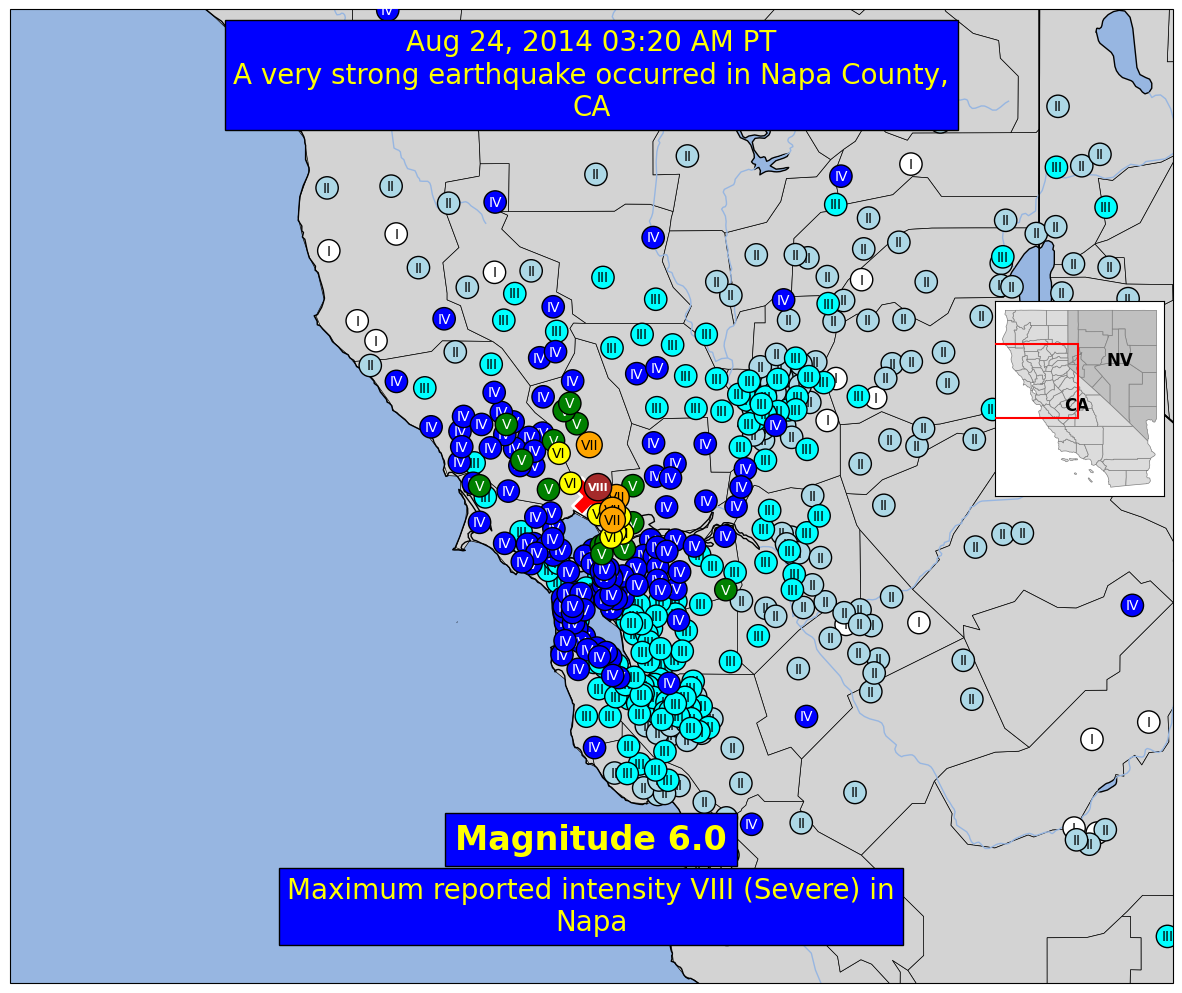

In [6]:
rm.get_mmi_data()
if rm.mmi_plottable:
    box_hl = rm.ev_mag/2 #box length depends on magnitude, unit: degrees
    epix, epiy = rm.ev_epix, rm.ev_epiy

    if not rm.dyfi_used:
    # map center defined by centroid of MMI dots, to avoid map being way off the coast
    # this method is better for losspager as that list is curated and keeps the closest important locations
        g_all = [Point(p) for p in rm.mmi_coord_pairs]+[Point(epix,epiy)]
        mmi_pts = gpd.GeoDataFrame(geometry=g_all)
        centroid = box(*mmi_pts.total_bounds).centroid
        x1, x2, y1, y2 = (centroid.x - box_hl, centroid.x + box_hl, centroid.y - box_hl/1.5, centroid.y + box_hl/1.5)
    else:
    # for dyfi, this method is better because dyfi reports can be scattered really far from the source in large earthquakes
    # still bad for offshore earthquakes. need a better method
        x1, x2, y1, y2 = epix - box_hl, epix + box_hl, epiy - box_hl/1.5, epiy + box_hl/1.5

    map_lims = (x1, x2, y1, y2)


    mmis = np.round(np.array(rm.mmis)).astype(int)
    max_mmi = np.max(mmis)
    _, _, _, _, maxnumeral, maxdesc = rm.mmi_style(max_mmi)
    rm.ev_maxnumeral = maxnumeral
    rm.ev_maxdesc = maxdesc

    max_ind = np.where(mmis == max_mmi)

    # list of cities where max. intensity was seen
    rm.cities_max_mmi = np.unique(np.array(rm.city_names)[max_ind])

    fig, axi = plt.subplots(1,1,figsize=(15,15), subplot_kw={'projection': ccrs.PlateCarree()})

    axi.add_feature(cfeature.LAND, edgecolor='black')
    axi.add_feature(cfeature.LAKES, edgecolor='black')
    axi.add_feature(cfeature.RIVERS)
    axi.add_feature(cfeature.STATES)
    axi.add_feature(cfeature.OCEAN)

    report_style = dict(boxstyle='square', facecolor='blue', edgecolor='black')
    n='\n' # newline variable

    # caption = f"An earthquake occurred {event['properties']['place']}"
    desc = rm.mag_style(rm.ev_mag)
    epi_mask = rm.ca_nv.contains(Point(epix,epiy))
    name_from_fp = lambda fp: "CA" if fp == '06' else "NV"
    if epi_mask.any():
        # if epicenter is within a polygon
        epi_county = rm.ca_nv[epi_mask]['NAME'].to_list()[0]
        epi_statefp = rm.ca_nv[epi_mask]['STATEFP'].to_list()[0]
        epi_state = name_from_fp(epi_statefp)
        caption = f'{desc} occurred in {epi_county} County, {epi_state}'
    else:
        #if epicenter is off all polygons (assumes offshore)
        # better method needed for events onshore off region (e.g. in Oregon, Utah, Mexico, etc.)
        county_closest = rm.ca_nv.distance(Point(epix,epiy)).sort_values().index[0]
        epi_county = rm.ca_nv.loc[county_closest]["NAME"]
        epi_statefp = rm.ca_nv.loc[county_closest]['STATEFP']
        epi_state = name_from_fp(epi_statefp)
        caption = f'{desc} occurred off {epi_county} County, {epi_state}'
    rm.mmi_report_caption = caption
    report_txt = f'{rm.ev_timestamp} PT\n{n.join(textwrap.wrap(caption,width=50))}'
    psa_style = dict(boxstyle='square', facecolor='blue', edgecolor='black')
    axi.text(0.5,0.98,report_txt,transform=axi.transAxes,fontsize=20,color='yellow',bbox=psa_style,va='top',ha='center',zorder=15)

    city_wrap = textwrap.wrap(", ".join(rm.cities_max_mmi[:10]), width=70)
    
    #change language depending on mmi data used
    if rm.dyfi_used:
        maxmmi_txt = f"Maximum reported intensity {maxnumeral} ({maxdesc}) in\n{n.join(city_wrap)}"
    else:
        maxmmi_txt = f"Maximum observed intensity {maxnumeral} ({maxdesc}) in\n{n.join(city_wrap)}"

    axi.text(0.5,0.13,f"Magnitude {rm.ev_mag}",transform=axi.transAxes,fontsize=24,color='yellow',fontweight='bold',bbox=report_style,va='bottom',ha='center',zorder=15)
    axi.text(0.5,0.11,maxmmi_txt,transform=axi.transAxes,fontsize=20,color='yellow',bbox=report_style,va='top',ha='center',zorder=15)

    rm.ca_nv.plot(ax=axi,color='lightgray',edgecolor='black',linewidth=0.5)

    for i, name in enumerate(rm.city_names):
        x,y = rm.mmi_coord_pairs[i][0],rm.mmi_coord_pairs[i][1]
        # don't plot points out of bounds
        if (x < x1 or x > x2) or (y < y1 or y > y2):
            continue
        mmi = mmis[i]
        box_color, txt_color, fnt_weight, fnt_size, numeral, _ = rm.mmi_style(mmi)
        mmi_bbox = dict(boxstyle='circle', facecolor=box_color, edgecolor='black')
        axi.text(
            x,y,numeral,
            bbox=mmi_bbox,
            c=txt_color,
            zorder=mmi+1,
            fontsize=fnt_size,
            fontweight=fnt_weight,
            clip_on=True
            )
        
    # in_map_counties = gpd.clip(rm.ca_nv,(x1,y1,x2,y2))
    # for j, county in in_map_counties.iterrows():
    #     centroid = county.geometry.representative_point()
    #     axi.annotate(
    #         text=county.NAME,
    #         xy=(centroid.x,centroid.y),
    #         c='gray',
    #         fontsize=6
    #     )

    axi.set_extent(map_lims)

    # minimap
    axins = axi.inset_axes([0.845,0.5,0.15,0.2])

    axins.text(0.66,0.67,"NV",transform=axins.transAxes,fontsize=12,fontweight='bold',color='black')
    axins.text(0.41,0.44,"CA",transform=axins.transAxes,fontsize=12,fontweight='bold',color='black')
    state_colors = rm.ca_nv['STATEFP'].map({'06': 'gainsboro', '32': 'silver'})
    rm.ca_nv.plot(ax=axins,color=state_colors,edgecolor='gray',linewidth=0.5)
    axins.set_xticks([])
    axins.set_yticks([])
    rect, lines = axins.indicate_inset_zoom(axi,edgecolor='red',linewidth=1.5,alpha=1.0)
    rect.set_clip_on(True)
    rect.set_clip_box(axins.bbox)
    for line in lines: 
        line.set_visible(False)


    axi.scatter(epix,epiy,marker='X',c='r',ec='white',linewidths=2,s=750)

plt.show()

In [ ]:
rm.ca_nv.contains(Point(epix,epiy)).any()